<a href="https://colab.research.google.com/github/MrSilva-HR/ProjectsHR/blob/main/Sistema_de_recomenda%C3%A7%C3%A3o_por_imagens_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install bing-image-downloader

from bing_image_downloader import downloader
import shutil
import os

# Vamos criar um catálogo misturado
if os.path.exists('dataset_produtos'):
    shutil.rmtree('dataset_produtos')

produtos = [
    "red nike running shoes",
    "blue denim jeans",
    "rolex submariner watch",
    "leather handbag women",
    "floral summer dress"
]

for item in produtos:
    downloader.download(
        item,
        limit=20,
        output_dir='dataset_produtos',
        adult_filter_off=True,
        force_replace=False,
        timeout=60,
        verbose=False
    )

print("✅ Estoque da loja baixado!")

[%] Downloading Images to /content/dataset_produtos/red nike running shoes
[!] Issue getting: https://editorialist.com/webcompressed/2023/8/025/830/147/25830147~black_0.png
[!] Error:: HTTP Error 403: Forbidden
[!] Issue getting: https://media.walkjogrun.net/wp-content/uploads/2021/06/Screen-Shot-2021-06-03-at-9.50.54-AM.png
[!] Error:: HTTP Error 522: <none>


[%] Done. Downloaded 20 images.
[%] Downloading Images to /content/dataset_produtos/blue denim jeans
[!] Issue getting: https://ean-images.booztcdn.com/the-new/1300x1700/tnwtn2056_clightbluedenim.jpg
[!] Error:: HTTP Error 403: Forbidden
[!] Issue getting: https://apparelbranded.com/wp-content/uploads/2017/12/blue-denim-2-free-img.jpg
[!] Error:: Remote end closed connection without response
[Error]Invalid image, not saving https://images.bewakoof.com/original/dark-blue-denim-jeans-479357-1680593592-2.jpg

[!] Issue getting: https://images.bewakoof.com/original/dark-blue-denim-jeans-479357-1680593592-2.jpg
[!] Error:: Invalid im

In [2]:
import os
import numpy as np
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from tqdm import tqdm # Barra de progresso

# 1. Carregar a ResNet50 (O "FaceNet" de objetos)
# include_top=False remove a camada final de classificação.
# pooling='avg' nos dá o vetor direto.
model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

# 2. Função para extrair características
def extrair_features(img_path, model):
    try:
        # ResNet espera imagens 224x224
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_expanded = np.expand_dims(img_array, axis=0)
        img_ready = preprocess_input(img_expanded) # Ajuste técnico da ResNet

        features = model.predict(img_ready, verbose=0)
        return features.flatten() # Retorna o vetor plano (1D)
    except Exception as e:
        print(f"Erro em {img_path}: {e}")
        return None

# 3. Indexar o Catálogo (Gerar Embeddings de tudo)
feature_list = []
image_paths = []

base_dir = 'dataset_produtos'
print("Indexando catálogo de produtos...")

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(root, file)
            feats = extrair_features(path, model)
            if feats is not None:
                feature_list.append(feats)
                image_paths.append(path)

feature_list = np.array(feature_list)
print(f"✅ Processado: {len(feature_list)} produtos indexados.")

# 4. Treinar o algoritmo de busca (KNN)
# Ele vai aprender quem está perto de quem no espaço vetorial
neighbors = NearestNeighbors(n_neighbors=5, algorithm='brute', metric='euclidean')
neighbors.fit(feature_list)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Indexando catálogo de produtos...
✅ Processado: 99 produtos indexados.


NearestNeighbors(algorithm='brute', metric='euclidean')

⬇️ Faça upload de um produto (Ex: foto de um relógio ou tênis):


Saving tenis .jpg to tenis .jpg


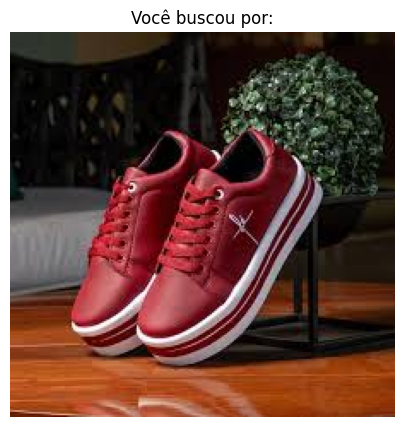


--- Produtos Semelhantes Encontrados: ---


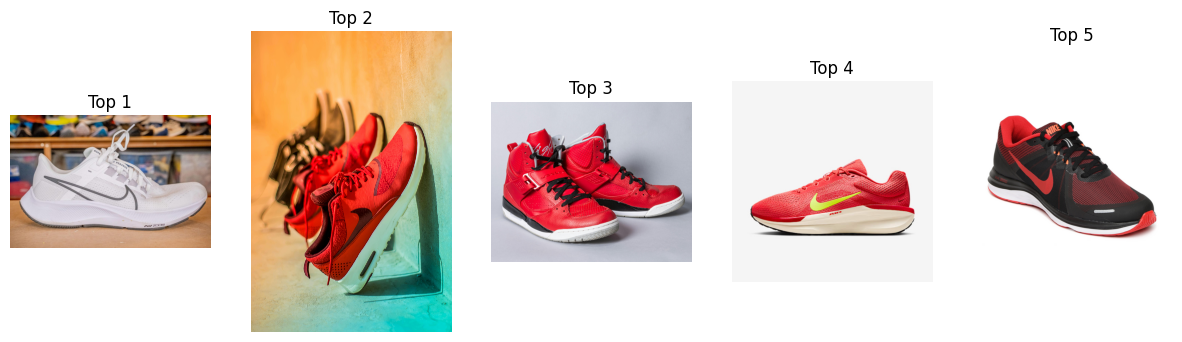

In [3]:
from google.colab import files
import cv2

def recomendar_por_imagem():
    print("⬇️ Faça upload de um produto (Ex: foto de um relógio ou tênis):")
    uploaded = files.upload()

    for filename in uploaded.keys():
        # 1. Extrair features da imagem nova
        query_features = extrair_features(filename, model)

        # 2. Encontrar os 5 vizinhos mais próximos
        distances, indices = neighbors.kneighbors([query_features])

        # 3. Exibir resultados
        # Imagem original
        img_query = cv2.imread(filename)
        img_query = cv2.cvtColor(img_query, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(5, 5))
        plt.imshow(img_query)
        plt.title("Você buscou por:")
        plt.axis('off')
        plt.show()

        # Recomendações
        print("\n--- Produtos Semelhantes Encontrados: ---")
        plt.figure(figsize=(15, 5))
        for i, idx in enumerate(indices[0]):
            img_path = image_paths[idx]
            img_res = cv2.imread(img_path)
            img_res = cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB)

            plt.subplot(1, 5, i + 1)
            plt.imshow(img_res)
            plt.title(f"Top {i+1}")
            plt.axis('off')
        plt.show()

# Rodar o teste
recomendar_por_imagem()

🛍️ Sistema de Recomendação Visual (Visual Search) com Deep Learning

Este projeto implementa um motor de recomendação por similaridade visual (semelhante ao Google Lens ou Pinterest). O sistema é capaz de receber a imagem de um produto (como um tênis ou relógio) e recomendar itens visualmente similares disponíveis no catálogo, utilizando Transfer Learning e Redes Neurais Convolucionais (CNNs).
🎯 Objetivo

Desenvolver uma ferramenta capaz de entender as características visuais (cor, forma, textura, padrão) de produtos de e-commerce e sugerir itens semelhantes, sem depender de tags de texto ou descrições manuais.

Cenário de Uso: O usuário gostou de um vestido florido, mas não sabe descrevê-lo. Ele envia a foto e o sistema retorna outros vestidos com estampa floral do banco de dados.
🧠 Conceito Teórico: Feature Extraction

Diferente da classificação tradicional (que diz "Isto é um gato"), este projeto foca na Extração de Características (Feature Extraction).

    ResNet50 (O Cérebro): Utilizamos uma rede neural profunda pré-treinada no dataset ImageNet (milhões de imagens).

    O "Pulo do Gato": Removemos a última camada da rede (a que classifica o objeto). Ao fazer isso, acessamos a penúltima camada, que contém um vetor numérico de 2048 posições.

    Embedding: Esse vetor é a "impressão digital" matemática da imagem. Imagens visualmente parecidas terão vetores matematicamente próximos.

🛠️ Arquitetura do Projeto

O pipeline foi dividido em 4 etapas principais:
1. Construção do Dataset

Automação da coleta de imagens utilizando a biblioteca bing-image-downloader para simular um catálogo de e-commerce variado.

    Categorias: Tênis (Running Shoes), Jeans, Relógios (Rolex), Bolsas e Vestidos.

2. Processamento (Feature Extraction)

Cada imagem do catálogo passa pela ResNet50.

    Entrada: Imagem (224x224 pixels).

    Processamento: A rede analisa bordas, texturas e formas complexas.

    Saída: Um vetor (array) de 2048 números.

3. Indexação e Busca (KNN)

Utilizamos o algoritmo K-Nearest Neighbors (KNN) ou "K-Vizinhos Mais Próximos".

    O algoritmo plota todos os produtos em um espaço multidimensional.

    Calcula-se a Distância Euclidiana entre os vetores.

4. Inferência (Recomendação)

Quando o usuário envia uma nova foto (Query):

    A foto passa pela ResNet50 -> Gera vetor.

    O KNN calcula quais são os 5 vetores do catálogo mais próximos (menor distância).

    O sistema exibe as imagens correspondentes.

💻 Tecnologias Utilizadas

    Python: Linguagem base.

    TensorFlow / Keras: Para carregar a ResNet50 e processar as imagens.

    Scikit-Learn: Para implementação do algoritmo KNN (NearestNeighbors).

    OpenCV & Matplotlib: Para manipulação e visualização das imagens.

    Bing Image Downloader: Para criação rápida do dataset.

🚀 Como Executar
Pré-requisitos
Bash

pip install tensorflow scikit-learn opencv-python matplotlib bing-image-downloader

Passo 1: Indexar o Catálogo

Execute o script principal para baixar as imagens e gerar o banco de vetores (features).
Python

# Trecho do código de extração
model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
features = model.predict(img_preprocessed)

Passo 2: Realizar Busca

Faça o upload de uma imagem de teste. O sistema retornará os "Top 5" itens mais parecidos visualmente.
📊 Resultados e Exemplos

O modelo demonstrou alta capacidade de generalização:

    Teste de Cores: Ao enviar um tênis vermelho, o sistema ignorou tênis de outras cores e priorizou os vermelhos.

    Teste de Formas: Ao enviar um relógio, o sistema diferenciou corretamente de outros objetos redondos, retornando apenas relógios.

    Teste de Padrões: Ao enviar um vestido florido, o sistema buscou outros vestidos com estampas complexas, ignorando vestidos lisos.

(Aqui você pode inserir o print do resultado que geramos no Colab)
🔮 Melhorias Futuras

Para evoluir este projeto para um ambiente de produção real:

    Banco de Dados Vetorial: Substituir o KNN simples por ferramentas como FAISS (Facebook AI Similarity Search) ou Pinecone para escalar para milhões de produtos.

    API Rest: Envelopar o modelo em uma API (FastAPI ou Flask) para ser consumido por um aplicativo mobile.

    Object Detection: Antes de recomendar, usar um modelo (como YOLO) para recortar o produto da foto do usuário, removendo o fundo para aumentar a precisão.

Desenvolvido como projeto de estudo em Visão Computacional e Deep Learning.